# Match Result Classification — Preprocessing & Model Comparison

**Target variable:** `result` (H = Home Win, A = Away Win, D = Draw)

**Pipeline steps:**
1. Load & Inspect
2. Row Filtering — drop rows with >40% missing
3. Drop outcome & identifier columns
4. Re-check column-level missingness
5. Handle missing values (median / mode imputation)
6. Datetime & time feature extraction
7. Feature engineering (in-match differentials)
8. Categorical encoding
9. Final checks
10. Produce `df_preprocessed` — chronological split + scaling
11. Save output
12. Model Training & Evaluation — six classifiers on `df_preprocessed`
13. Model Comparison

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

---
## 1. Load & Inspect

In [ ]:
# Update this path if the CSV is in a different location
DATA_PATH = 'scraped_dataset.csv'  

df = pd.read_csv(DATA_PATH, low_memory=False)

print('Shape:', df.shape)
print('\nColumn dtypes:')
print(df.dtypes.value_counts())
print('\nTarget distribution:')
print(df['result'].value_counts())
df.head(3)


Shape: (16688, 109)

Column dtypes:
float64    92
str        13
int64       4
Name: count, dtype: int64

Target distribution:
result
H    7457
A    5114
D    4115
Name: count, dtype: int64


,match_id,league_division,season,round,date,kickoff_time,attendance,capacity,stadium,city,home_team,away_team,home_goals,away_goals,result,home_formation,away_formation,home_team_rating,away_team_rating,home_shots_total,away_shots_total,home_shots_on_target,away_shots_on_target,home_shots_off_target,away_shots_off_target,home_shots_inside_box,away_shots_inside_box,home_shots_outside_box,away_shots_outside_box,home_headed_goals,away_headed_goals,home_hit_woodwork,away_hit_woodwork,home_corners,away_corners,home_free_kicks,away_free_kicks,home_throw_ins,away_throw_ins,home_fouls_committed,away_fouls_committed,home_offsides,away_offsides,home_yellow_cards,away_yellow_cards,home_red_cards,away_red_cards,home_goalkeeper_saves,away_goalkeeper_saves,home_possession_pct,away_possession_pct,home_touches_opp_box,away_touches_opp_box,home_passes_pct,away_passes_pct,home_passes_successful,away_passes_successful,home_passes_total,away_passes_total,home_long_passes_pct,away_long_passes_pct,home_long_passes_successful,away_long_passes_successful,home_long_passes_total,away_long_passes_total,home_passes_final_third_pct,away_passes_final_third_pct,home_passes_final_third_successful,away_passes_final_third_successful,home_passes_final_third_total,away_passes_final_third_total,home_crosses_pct,away_crosses_pct,home_crosses_successful,away_crosses_successful,home_crosses_total,away_crosses_total,home_big_chances,away_big_chances,home_duels_won,away_duels_won,home_errors_leading_to_shot,away_errors_leading_to_shot,home_errors_leading_to_goal,away_errors_leading_to_goal,home_accurate_through_passes,away_accurate_through_passes,home_tackles_pct,away_tackles_pct,home_tackles_successful,away_tackles_successful,home_tackles_total,away_tackles_total,home_shots_blocked,away_shots_blocked,home_clearances,away_clearances,home_interceptions,away_interceptions,home_xg,away_xg,home_xgot,away_xgot,home_xa,away_xa,home_xgot_faced,away_xgot_faced,home_goals_prevented,away_goals_prevented
0,Ghrg3y4k,CAF Champions League,2024-2025,Semi-finals,"August 24, 2024",05:00 PM,NaN,NaN,NaN,NaN,Jwaneng Galaxy (Bot),African Stars (Nam),2.0,0.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KMdN8ctS,CAF Champions League,2024-2025,Semi-finals,"August 17, 2024",04:00 PM,NaN,NaN,NaN,NaN,African Stars (Nam),Jwaneng Galaxy (Bot),1.0,0.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8dbp3ZfU,CAF Champions League,2024-2025,Quarter-finals,"April 01, 2025",09:00 PM,NaN,30000.0,Al Salam Stadium,Cairo,Al Ahly,Al-Hilal Omdurman,1.0,0.0,H,4-2-3-1,4-2-3-1,6.9,8.1,12.0,6.0,4.0,2.0,6.0,4.0,9.0,3.0,3.0,3.0,NaN,NaN,0.0,0.0,8.0,2.0,7.0,22.0,20.0,17.0,22.0,7.0,1.0,1.0,3,1,0,0,2.0,3.0,68.0,32.0,26.0,7.0,85.0,60.0,450.0,147.0,527.0,247.0,50.0,23.0,30.0,13.0,60.0,56.0,79.0,49.0,122.0,39.0,154.0,79.0,32.0,0.0,7.0,0.0,22.0,6.0,1.0,0.0,56.0,64.0,0.0,0.0,0.0,0.0,0.0,0.0,47.0,74.0,8.0,17.0,17.0,23.0,2.0,0.0,10.0,13.0,11.0,12.0,0.77,0.16,1.29,0.19,1.1,0.16,0.19,1.29,0.19,0.29


---
## 2. Row Filtering — Drop Rows with >40% Missing Columns

**Decision on >20% threshold:**  
Rows with 20–40% missing are kept. Those rows still have core match stats intact (possession, shots, cards, etc.);  
what's missing is mainly advanced metrics (xG, long-pass breakdowns, errors leading to shot).  
Dropping them would waste ~2,651 additional rows for no benefit — those columns will be handled by imputation.

Also dropping the 1 row where `result` is null (target is missing — unusable) and the 1 row where `date` is null.

In [ ]:
# Row-level missing percentage
row_missing_pct = df.isnull().mean(axis=1)

print('--- Row-level missing summary (before filtering) ---')
print(f'Total rows:                       {len(df):>6}')
print(f'Complete rows (0% missing):       {(row_missing_pct == 0).sum():>6}')
print(f'Rows with >=1 missing:            {(row_missing_pct > 0).sum():>6}')
print(f'Rows with >20% missing columns:   {(row_missing_pct > 0.20).sum():>6}')
print(f'Rows with >40% missing columns:   {(row_missing_pct > 0.40).sum():>6}')
print(f'Rows with >50% missing columns:   {(row_missing_pct > 0.50).sum():>6}')
print(f'Rows with >80% missing columns:   {(row_missing_pct > 0.80).sum():>6}')


--- Row-level missing summary (before filtering) ---
Total rows:                        16688
Complete rows (0% missing):         2758
Rows with >=1 missing:             13930
Rows with >20% missing columns:     7284
Rows with >40% missing columns:     4633
Rows with >50% missing columns:     4129
Rows with >80% missing columns:      459


In [ ]:
# Drop rows with >40% missing
df = df[row_missing_pct <= 0.40].copy()

# Drop the single rows where target or date is null
df = df.dropna(subset=['result', 'date'])

print('Shape after row filtering:', df.shape)
print('Target distribution:')
print(df['result'].value_counts())


Shape after row filtering: (12054, 109)
Target distribution:
result
H    5385
A    3679
D    2990
Name: count, dtype: int64


---
## 3. Drop Outcome & Identifier Columns

**Outcome columns — data leakage (dropped):**
- `home_goals`, `away_goals` — directly encode the result; keeping them would let any model trivially solve the task.
- `home_headed_goals`, `away_headed_goals` — subset of goals, same issue.

**Identifier / high-cardinality columns (dropped):**
- `match_id` — unique per row, no signal.
- `home_team`, `away_team` — ~1,289 / 1,281 unique values. Too high-cardinality for direct encoding.  
  Drop now; revisit when you add sliding window team-level features later.
- `stadium`, `city` — ~1,350 / 1,007 unique values, same reason.


In [ ]:
outcome_cols    = ['home_goals', 'away_goals', 'home_headed_goals', 'away_headed_goals']
identifier_cols = ['match_id', 'stadium', 'city']

# Keep home_team / away_team in df for now — needed to compute rolling features.
# They will be dropped AFTER rolling features are computed in Section 11.
drop_cols = outcome_cols + identifier_cols
df.drop(columns=drop_cols, inplace=True)

print('Dropped:', drop_cols)
print('home_team and away_team are kept for rolling feature computation.')
print('Shape after dropping:', df.shape)

Dropped: ['home_goals', 'away_goals', 'home_headed_goals', 'away_headed_goals', 'match_id', 'stadium', 'city']
home_team and away_team are kept for rolling feature computation.
Shape after dropping: (12054, 102)


---
## 4. Re-check Column-Level Missingness

After row filtering the per-column missing % changes — always re-check before deciding imputation strategy.


In [ ]:
missing_counts = df.isnull().sum()
missing_pct    = (missing_counts / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct':   missing_pct
}).sort_values('missing_pct', ascending=False)

missing_report = missing_report[missing_report['missing_count'] > 0]

print('Columns with at least 1 missing value:', len(missing_report))
missing_report


Columns with at least 1 missing value: 57


,missing_count,missing_pct
home_errors_leading_to_goal,2752,22.83
away_errors_leading_to_goal,2752,22.83
home_errors_leading_to_shot,2734,22.68
away_errors_leading_to_shot,2734,22.68
away_accurate_through_passes,2718,22.55
home_accurate_through_passes,2718,22.55
home_long_passes_pct,2652,22.00
away_long_passes_pct,2652,22.00
home_long_passes_total,2652,22.00
away_long_passes_total,2652,22.00


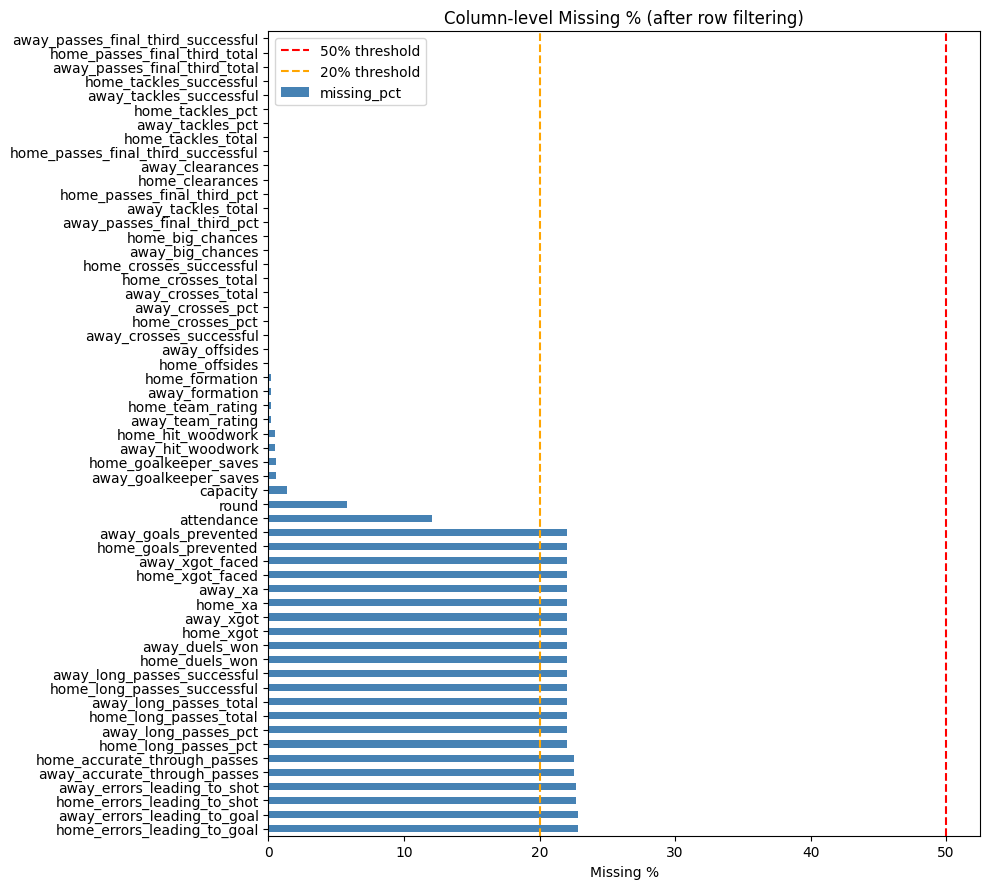

In [ ]:
fig, ax = plt.subplots(figsize=(10, 9))
missing_report['missing_pct'].plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(x=50, color='red',    linestyle='--', label='50% threshold')
ax.axvline(x=20, color='orange', linestyle='--', label='20% threshold')
ax.set_xlabel('Missing %')
ax.set_title('Column-level Missing % (after row filtering)')
ax.legend()
plt.tight_layout()
plt.show()


---
## 5. Handle Missing Values in Columns

| Column group | Missing % | Action | Reason |
|---|---|---|---|
| `*_errors_leading_to_*`, `*_accurate_through_passes`, `*_long_passes_*`, `*_xgot*`, `*_xa`, `*_goals_prevented`, `*_duels_won` | ~22% | **Median** | Numeric, right-skewed |
| `attendance` | ~12% | **Median** | Numeric, right-skewed |
| `round` | ~5.8% | **Mode** | Categorical |
| `capacity`, goalkeeper saves, hit woodwork, team rating, crosses, offsides, passes, tackles | <2% | **Median** | Numeric, few nulls |
| `home_formation`, `away_formation` | ~0.15% | **Mode** | Categorical |
| `kickoff_time` | 1 row | **Mode** | Categorical, trivially small |


In [ ]:
# ── Numeric columns: median imputation ──────────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
medians = df[numeric_cols].median()
df[numeric_cols] = df[numeric_cols].fillna(medians)

print('Numeric columns imputed with median.')

# ── Categorical columns: mode imputation ─────────────────────────────────────
cat_impute_cols = ['round', 'home_formation', 'away_formation', 'kickoff_time', 'league_division']
for col in cat_impute_cols:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print('Categorical columns imputed with mode.')

# ── Verify ────────────────────────────────────────────────────────────────────
remaining_nulls = df.isnull().sum().sum()
print('Total remaining nulls:', remaining_nulls)


Numeric columns imputed with median.
Categorical columns imputed with mode.
Total remaining nulls: 0


---
## 6. Datetime & Time Feature Extraction


In [ ]:
# ── date → month, day_of_week, year ─────────────────────────────────────────
df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')

df['match_month']       = df['date'].dt.month          # 1–12
df['match_day_of_week'] = df['date'].dt.dayofweek      # 0=Monday … 6=Sunday
df['match_year']        = df['date'].dt.year

df = df.drop(columns=['date'])

# ── kickoff_time → hour integer (0–23) ───────────────────────────────────────
# Primary format: '05:00 PM'
df['kickoff_hour'] = pd.to_datetime(
    df['kickoff_time'], format='%I:%M %p', errors='coerce'
).dt.hour

# Fallback: try 24-hour format for any that failed
mask = df['kickoff_hour'].isnull()
df.loc[mask, 'kickoff_hour'] = pd.to_datetime(
    df.loc[mask, 'kickoff_time'], format='%H:%M', errors='coerce'
).dt.hour

df['kickoff_hour'] = df['kickoff_hour'].fillna(df['kickoff_hour'].mode()[0]).astype(int)
df = df.drop(columns=['kickoff_time'])

# ── season → start year integer ───────────────────────────────────────────────
# Values in data: '2024-2025', '2025-2026', '2026', '2025'
df['season_year'] = df['season'].astype(str).str[:4].astype(int)
df = df.drop(columns=['season'])

print('Date/time features extracted.')
print(df[['match_month', 'match_day_of_week', 'match_year', 'kickoff_hour', 'season_year']].head())


Date/time features extracted.
   match_month  match_day_of_week  match_year  kickoff_hour  season_year
2            4                  1        2025            21         2024
3            4                  1        2025            21         2024
5            1                  4        2025            21         2024
8            4                  5        2025            15         2024
9            4                  4        2025            19         2024


---
## 7. Feature Engineering

Differential features (home − away) capture *relative* team performance, which is more directly tied to the match outcome  
than raw home or away values alone. All features are derived from in-match stats — no additional leakage.

> ⚠️ All features here are in-match stats. If you switch to pre-match prediction later, these must also be dropped.


In [ ]:
# ── Differential features (home − away) ─────────────────────────────────────
new_features = {
    'diff_shots_total':     df['home_shots_total']      - df['away_shots_total'],
    'diff_shots_on_target': df['home_shots_on_target']  - df['away_shots_on_target'],
    'diff_possession':      df['home_possession_pct']   - df['away_possession_pct'],
    'diff_big_chances':     df['home_big_chances']      - df['away_big_chances'],
    'diff_xg':              df['home_xg']               - df['away_xg'],
    'diff_passes_pct':      df['home_passes_pct']       - df['away_passes_pct'],
    'diff_corners':         df['home_corners']          - df['away_corners'],
    'diff_fouls':           df['home_fouls_committed']  - df['away_fouls_committed'],
    'diff_yellow_cards':    df['home_yellow_cards']     - df['away_yellow_cards'],
    'diff_tackles_pct':     df['home_tackles_pct']      - df['away_tackles_pct'],
}

# ── Shot accuracy (on-target / total) ────────────────────────────────────────
new_features['home_shot_accuracy'] = np.where(
    df['home_shots_total'] > 0, df['home_shots_on_target'] / df['home_shots_total'], 0
)
new_features['away_shot_accuracy'] = np.where(
    df['away_shots_total'] > 0, df['away_shots_on_target'] / df['away_shots_total'], 0
)
new_features['diff_shot_accuracy'] = (
    new_features['home_shot_accuracy'] - new_features['away_shot_accuracy']
)

# ── Stadium utilisation rate ──────────────────────────────────────────────────
fill_rate = np.where(df['capacity'] > 0, df['attendance'] / df['capacity'], np.nan)
new_features['attendance_fill_rate'] = pd.Series(fill_rate, index=df.index).fillna(
    pd.Series(fill_rate, index=df.index).median()
)

# Assign all new features at once (avoids DataFrame fragmentation warning)
df = pd.concat([df, pd.DataFrame(new_features, index=df.index)], axis=1)

print('Feature engineering done. New shape:', df.shape)


Feature engineering done. New shape: (12054, 118)


---
## 8. Categorical Encoding

All categorical columns are label-encoded:
- `result` (target: H/A/D → 0/1/2)
- `league_division` (55 unique) — too many for one-hot; label encoding keeps it lean
- `round` (51 unique, mix of numbers and labels like 'Final', 'Semi-finals')
- `home_formation`, `away_formation` (29–31 unique)


In [ ]:
le = LabelEncoder()

# Target
df['result'] = le.fit_transform(df['result'])
result_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('result encoding:', result_mapping)

# Features
for col in ['league_division', 'round', 'home_formation', 'away_formation']:
    df[col] = le.fit_transform(df[col].astype(str))

print('Encoding complete.')
print('Remaining object columns:', df.select_dtypes(include='object').columns.tolist())


result encoding: {'A': np.int64(0), 'D': np.int64(1), 'H': np.int64(2)}
Encoding complete.
Remaining object columns: ['home_team', 'away_team']


C:\Users\omara\AppData\Local\Temp\ipykernel_21876\259155873.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print('Remaining object columns:', df.select_dtypes(include='object').columns.tolist())


---
## 9. Final Checks


In [ ]:
print('Final shape:', df.shape)
print('Remaining nulls:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print('All dtypes numeric:', (df.dtypes != object).all())
print('\nTarget distribution:')
print(df['result'].value_counts())
df.describe().T


Final shape: (12054, 118)
Remaining nulls: 0
Duplicate rows: 0
All dtypes numeric: True

Target distribution:
result
2    5385
0    3679
1    2990
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
league_division,12054.0,24.795669,13.686362,0.000000,14.000000,29.000000,36.000000,52.000000
round,12054.0,23.376887,15.014495,0.000000,11.000000,21.000000,37.000000,50.000000
attendance,12054.0,21669.468226,16244.750333,76.000000,10491.750000,18236.500000,27656.750000,85015.000000
capacity,12054.0,30663.932968,19194.437855,1000.000000,16200.000000,26000.000000,40670.000000,105000.000000
result,12054.0,1.141530,0.855558,0.000000,0.000000,1.000000,2.000000,2.000000
...,...,...,...,...,...,...,...,...
diff_tackles_pct,12054.0,0.530861,18.542714,-75.000000,-11.000000,0.000000,13.000000,72.000000
home_shot_accuracy,12054.0,0.347659,0.146578,0.000000,0.250000,0.333333,0.437500,1.000000
away_shot_accuracy,12054.0,0.347102,0.165478,0.000000,0.235294,0.333333,0.444444,1.000000
diff_shot_accuracy,12054.0,0.000557,0.224395,-0.933333,-0.145833,0.000000,0.150000,1.000000


---
## 10. Produce `df_preprocessed` — Chronological Split + Correct Scaling

**Scaling rules applied:**
1. Sort chronologically
2. 80/20 chronological split (no random shuffle — preserves temporal order)
3. `scaler.fit()` on **train only**
4. `scaler.transform()` on train and test **separately**
5. Recombine with a `split` column (`'train'` / `'test'`) for traceability

`df_preprocessed` contains all in-match features — for use with tree-based and
distance/gradient-based models alike.

In [ ]:
# ── Sort chronologically ─────────────────────────────────────────────────────
df_prep = df.copy()
df_prep = df_prep.sort_values(['match_year', 'match_month']).reset_index(drop=True)

# ── Drop team name columns (not encoded — can't scale) ────────────────────────
df_prep = df_prep.drop(columns=['home_team', 'away_team'], errors='ignore')

# ── Chronological 80/20 split ─────────────────────────────────────────────────
split_idx = int(len(df_prep) * 0.80)
train_prep = df_prep.iloc[:split_idx].copy()
test_prep  = df_prep.iloc[split_idx:].copy()

print(f'Train rows: {len(train_prep)} | Test rows: {len(test_prep)}')
print(f'Train covers up to row index {split_idx - 1}, test from {split_idx}')

# ── Separate features and target ──────────────────────────────────────────────
feature_cols = [c for c in df_prep.columns if c != 'result']

X_train_prep = train_prep[feature_cols]
X_test_prep  = test_prep[feature_cols]
y_train_prep = train_prep['result']
y_test_prep  = test_prep['result']

# ── Fit scaler on train ONLY, transform train and test separately ─────────────
scaler_prep = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler_prep.fit_transform(X_train_prep),
    columns=feature_cols, index=X_train_prep.index
)
X_test_scaled = pd.DataFrame(
    scaler_prep.transform(X_test_prep),
    columns=feature_cols, index=X_test_prep.index
)

# ── Recombine into df_preprocessed with split label ──────────────────────────
train_out = X_train_scaled.copy()
train_out['result'] = y_train_prep.values
train_out['split']  = 'train'

test_out = X_test_scaled.copy()
test_out['result'] = y_test_prep.values
test_out['split']  = 'test'

df_preprocessed = pd.concat([train_out, test_out], axis=0).reset_index(drop=True)

print('\ndf_preprocessed shape:', df_preprocessed.shape)
print('Split distribution:')
print(df_preprocessed['split'].value_counts())
print('\nSample train scaled means (should be ~0.0):')
print(X_train_scaled.mean().head(5).round(4))
print('\nSample train scaled stds (should be ~1.0):')
print(X_train_scaled.std().head(5).round(4))

Train rows: 9643 | Test rows: 2411
Train covers up to row index 9642, test from 9643

df_preprocessed shape: (12054, 117)
Split distribution:
split
train    9643
test     2411
Name: count, dtype: int64

Sample train scaled means (should be ~0.0):
league_division    0.0
round             -0.0
attendance        -0.0
capacity           0.0
home_formation    -0.0
dtype: float64

Sample train scaled stds (should be ~1.0):
league_division    1.0001
round              1.0001
attendance         1.0001
capacity           1.0001
home_formation     1.0001
dtype: float64


In [ ]:
# ── Drop temporal ID columns from df_preprocessed ────────────────────────────
# match_year and season_year are dropped so models don't learn spurious
# year-specific patterns (e.g. "2026 matches are different").
# Chronological split already prevents leakage; these columns add no signal.

drop_temporal = ['match_year', 'season_year']

X_train_scaled = X_train_scaled.drop(columns=drop_temporal, errors='ignore')
X_test_scaled  = X_test_scaled.drop(columns=drop_temporal, errors='ignore')

# Rebuild df_preprocessed without the dropped columns
feature_cols = [c for c in X_train_scaled.columns]

train_out = X_train_scaled.copy()
train_out['result'] = y_train_prep.values
train_out['split']  = 'train'

test_out = X_test_scaled.copy()
test_out['result'] = y_test_prep.values
test_out['split']  = 'test'

df_preprocessed = pd.concat([train_out, test_out], axis=0).reset_index(drop=True)

print('Dropped temporal columns from df_preprocessed:', drop_temporal)
print('df_preprocessed shape after drop:', df_preprocessed.shape)


Dropped temporal columns from df_preprocessed: ['match_year', 'season_year']
df_preprocessed shape after drop: (12054, 115)


---
## 11. Save Output

In [ ]:
# df_preprocessed: full in-match pipeline, correctly scaled
df_preprocessed.to_csv('df_preprocessed_2.csv', index=False)

print('Saved: df_preprocessed.csv  →', df_preprocessed.shape)
print()
print('Chronological 80/20 split. Scaler fit on train only.')
print("'split' column marks train/test rows.")


Saved: df_preprocessed.csv  → (12054, 115)

Chronological 80/20 split. Scaler fit on train only.
'split' column marks train/test rows.


---
## 12. Model Training & Evaluation — `df_preprocessed`

Six classifiers trained on the **in-match dataset**.  
All use the **chronological 80/20 split** already encoded in the `split` column.

| Model | Class-imbalance handling |
|---|---|
| Logistic Regression | `class_weight='balanced'` |
| Linear SVM | `class_weight='balanced'` |
| K-Nearest Neighbours | — (no native support) |
| Gaussian Naive Bayes | — (no native support) |
| XGBoost | `compute_sample_weight` balanced |
| ANN (MLP) | `compute_class_weight` → weighted loss |

**Metrics reported per model:** Accuracy · Macro Precision · Macro Recall · Macro F1 · ROC-AUC OvR  
Per-class Precision / Recall / F1 for A (Away win) · D (Draw) · H (Home win)  
Confusion Matrix

In [ ]:
# ── Shared setup ──────────────────────────────────────────────────────────────
from sklearn.linear_model  import LogisticRegression
from sklearn.svm           import LinearSVC
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.naive_bayes   import GaussianNB
from sklearn.calibration   import CalibratedClassifierCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics       import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, auc as sk_auc
)
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')

CLASSES      = np.array([0, 1, 2])   # 0=A (Away win), 1=D (Draw), 2=H (Home win)
CLASS_LABELS = ['Away Win (A)', 'Draw (D)', 'Home Win (H)']
CLASS_SHORT  = ['A', 'D', 'H']
PALETTE      = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948']
SHORT_NAMES  = ['LR', 'SVM', 'KNN', 'GNB', 'XGB', 'ANN']

# ── Extract train / test ───────────────────────────────────────────────────────
_train = df_preprocessed[df_preprocessed['split'] == 'train'].copy()
_test  = df_preprocessed[df_preprocessed['split'] == 'test'].copy()

feat_cols = [c for c in df_preprocessed.columns if c not in ('result', 'split')]

X_tr = _train[feat_cols].values
y_tr = _train['result'].values.astype(int)
X_te = _test[feat_cols].values
y_te = _test['result'].values.astype(int)

y_te_bin = label_binarize(y_te, classes=CLASSES)

print('Setup complete.')
print(f'Train: {X_tr.shape} | Test: {X_te.shape}')
print(f'Class dist in train — A:{(y_tr==0).sum()}  D:{(y_tr==1).sum()}  H:{(y_tr==2).sum()}')


Setup complete.
Train: (9643, 113) | Test: (2411, 113)
Class dist in train — A:2936  D:2374  H:4333


In [ ]:
# ── Helper: full metric report + confusion matrix ─────────────────────────────
def print_metrics(name, y_true, y_pred, y_prob):
    acc   = accuracy_score(y_true, y_pred)
    mac_p = precision_score(y_true, y_pred, average='macro', zero_division=0)
    mac_r = recall_score(y_true, y_pred, average='macro', zero_division=0)
    mac_f = f1_score(y_true, y_pred, average='macro', zero_division=0)
    auc   = roc_auc_score(label_binarize(y_true, classes=CLASSES), y_prob,
                          multi_class='ovr', average='macro')
    p_cls = precision_score(y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    r_cls = recall_score(y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    f_cls = f1_score(y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    cm    = confusion_matrix(y_true, y_pred, labels=CLASSES)

    bar = '═' * 62
    print(f'\n{bar}')
    print(f'  {name}')
    print(bar)
    print(f'  Accuracy        : {acc:.4f}')
    print(f'  Macro Precision : {mac_p:.4f}')
    print(f'  Macro Recall    : {mac_r:.4f}')
    print(f'  Macro F1        : {mac_f:.4f}')
    print(f'  ROC-AUC (OvR)   : {auc:.4f}')
    print()
    print(f'  {"Class":<18} {"Precision":>10} {"Recall":>10} {"F1":>10}')
    print(f'  {"-"*50}')
    for lbl, p, r, f in zip(CLASS_LABELS, p_cls, r_cls, f_cls):
        print(f'  {lbl:<18} {p:>10.4f} {r:>10.4f} {f:>10.4f}')

    fig, ax = plt.subplots(figsize=(4.5, 3.8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_SHORT, yticklabels=CLASS_SHORT, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout(); plt.show()

    return {
        'name': name,
        'accuracy': acc, 'macro_precision': mac_p,
        'macro_recall': mac_r, 'macro_f1': mac_f, 'roc_auc': auc,
        'precision_per_class': p_cls, 'recall_per_class': r_cls,
        'f1_per_class': f_cls, 'confusion_matrix': cm, 'y_prob': y_prob
    }

all_results = []
print('Helper loaded.')


Helper loaded.



══════════════════════════════════════════════════════════════
  Logistic Regression
══════════════════════════════════════════════════════════════
  Accuracy        : 0.9079
  Macro Precision : 0.8982
  Macro Recall    : 0.8982
  Macro F1        : 0.8981
  ROC-AUC (OvR)   : 0.9747

  Class               Precision     Recall         F1
  --------------------------------------------------
  Away Win (A)           0.9350     0.9098     0.9222
  Draw (D)               0.8136     0.8360     0.8247
  Home Win (H)           0.9460     0.9487     0.9473


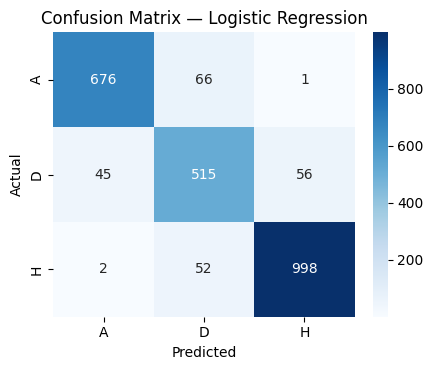

In [ ]:
# ── 1. Logistic Regression ────────────────────────────────────────────────────
lr = LogisticRegression(solver='lbfgs', class_weight='balanced',
                        max_iter=1000, random_state=42)
lr.fit(X_tr, y_tr)
res_lr = print_metrics('Logistic Regression', y_te, lr.predict(X_te), lr.predict_proba(X_te))
all_results.append(res_lr)



══════════════════════════════════════════════════════════════
  Linear SVM
══════════════════════════════════════════════════════════════
  Accuracy        : 0.8835
  Macro Precision : 0.8747
  Macro Recall    : 0.8621
  Macro F1        : 0.8651
  ROC-AUC (OvR)   : 0.9430

  Class               Precision     Recall         F1
  --------------------------------------------------
  Away Win (A)           0.8637     0.9381     0.8994
  Draw (D)               0.8449     0.6899     0.7596
  Home Win (H)           0.9155     0.9582     0.9364


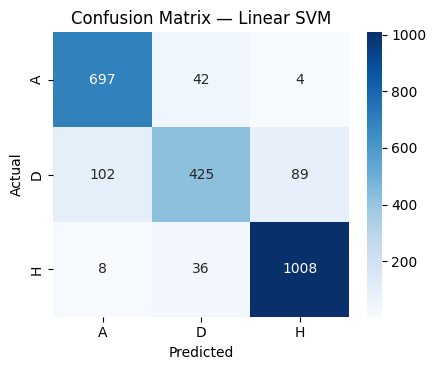

In [ ]:
# ── 2. Linear SVM ─────────────────────────────────────────────────────────────
svm_base = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)
svm = CalibratedClassifierCV(svm_base, cv=3)
svm.fit(X_tr, y_tr)
res_svm = print_metrics('Linear SVM', y_te, svm.predict(X_te), svm.predict_proba(X_te))
all_results.append(res_svm)



══════════════════════════════════════════════════════════════
  KNN (k=11)
══════════════════════════════════════════════════════════════
  Accuracy        : 0.6889
  Macro Precision : 0.6597
  Macro Recall    : 0.6491
  Macro F1        : 0.6514
  ROC-AUC (OvR)   : 0.8400

  Class               Precision     Recall         F1
  --------------------------------------------------
  Away Win (A)           0.7791     0.6931     0.7336
  Draw (D)               0.4597     0.3977     0.4265
  Home Win (H)           0.7403     0.8565     0.7942


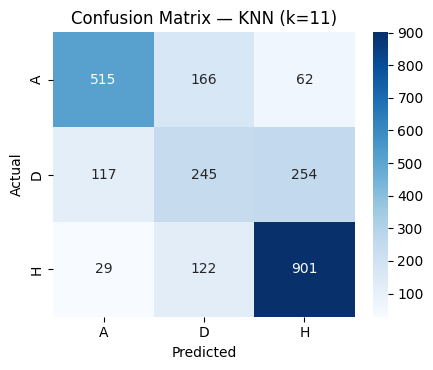

In [ ]:
# ── 3. K-Nearest Neighbours ───────────────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=11, metric='euclidean', weights='distance')
knn.fit(X_tr, y_tr)
res_knn = print_metrics('KNN (k=11)', y_te, knn.predict(X_te), knn.predict_proba(X_te))
all_results.append(res_knn)



══════════════════════════════════════════════════════════════
  Gaussian Naive Bayes
══════════════════════════════════════════════════════════════
  Accuracy        : 0.6466
  Macro Precision : 0.6381
  Macro Recall    : 0.6332
  Macro F1        : 0.6323
  ROC-AUC (OvR)   : 0.8130

  Class               Precision     Recall         F1
  --------------------------------------------------
  Away Win (A)           0.6899     0.6797     0.6847
  Draw (D)               0.4197     0.5260     0.4669
  Home Win (H)           0.8049     0.6939     0.7453


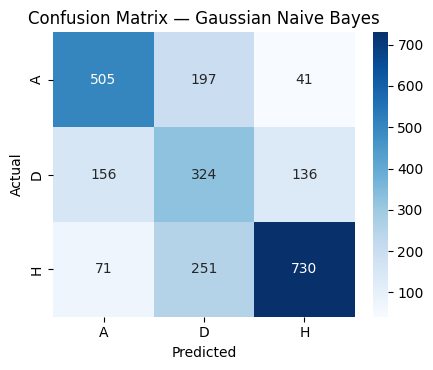

In [ ]:
# ── 4. Gaussian Naive Bayes ───────────────────────────────────────────────────
gnb = GaussianNB()
gnb.fit(X_tr, y_tr)
res_gnb = print_metrics('Gaussian Naive Bayes', y_te, gnb.predict(X_te), gnb.predict_proba(X_te))
all_results.append(res_gnb)



══════════════════════════════════════════════════════════════
  XGBoost
══════════════════════════════════════════════════════════════
  Accuracy        : 0.8835
  Macro Precision : 0.8711
  Macro Recall    : 0.8723
  Macro F1        : 0.8714
  ROC-AUC (OvR)   : 0.9696

  Class               Precision     Recall         F1
  --------------------------------------------------
  Away Win (A)           0.9062     0.8708     0.8881
  Draw (D)               0.7657     0.8117     0.7880
  Home Win (H)           0.9416     0.9344     0.9380


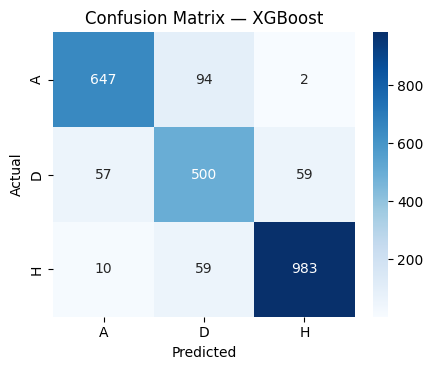

In [ ]:
# ── 5. XGBoost ────────────────────────────────────────────────────────────────
sw = compute_sample_weight(class_weight='balanced', y=y_tr)
xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3, n_estimators=300,
    max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, verbosity=0
)
xgb_clf.fit(X_tr, y_tr, sample_weight=sw)
res_xgb = print_metrics('XGBoost', y_te, xgb_clf.predict(X_te), xgb_clf.predict_proba(X_te))
all_results.append(res_xgb)


ANN class weights: {0: np.float64(1.095), 1: np.float64(1.354), 2: np.float64(0.742)}
Training stopped at epoch 18


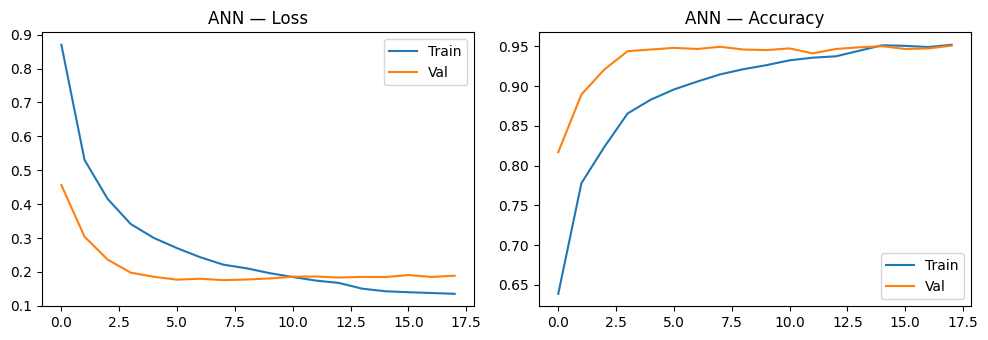


══════════════════════════════════════════════════════════════
  ANN (MLP 128→64)
══════════════════════════════════════════════════════════════
  Accuracy        : 0.9029
  Macro Precision : 0.8923
  Macro Recall    : 0.8919
  Macro F1        : 0.8921
  ROC-AUC (OvR)   : 0.9758

  Class               Precision     Recall         F1
  --------------------------------------------------
  Away Win (A)           0.9137     0.9260     0.9198
  Draw (D)               0.8201     0.8068     0.8134
  Home Win (H)           0.9430     0.9430     0.9430


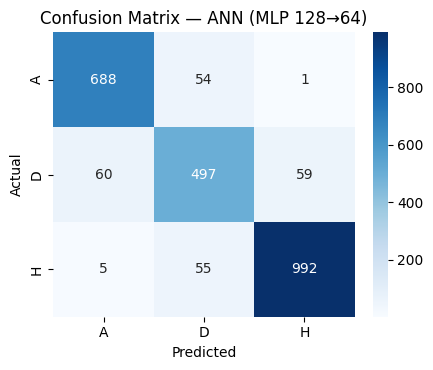

In [ ]:
# ── 6. ANN (MLP) ──────────────────────────────────────────────────────────────
tf.random.set_seed(42); np.random.seed(42)

cw_vals = compute_class_weight(class_weight='balanced', classes=CLASSES, y=y_tr)
cw_dict = {0: cw_vals[0], 1: cw_vals[1], 2: cw_vals[2]}
print('ANN class weights:', {k: round(v, 3) for k, v in cw_dict.items()})

ann = keras.Sequential([
    keras.layers.Input(shape=(X_tr.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(3, activation='softmax')
], name='ANN_classifier')

ann.compile(optimizer=keras.optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = ann.fit(
    X_tr, y_tr, validation_split=0.15, epochs=100, batch_size=64,
    class_weight=cw_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
    ], verbose=0
)
print(f'Training stopped at epoch {len(history.history["loss"])}')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history.history['loss'], label='Train'); axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('ANN — Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='Train'); axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('ANN — Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

y_prob_ann = ann.predict(X_te, verbose=0)
y_pred_ann = np.argmax(y_prob_ann, axis=1)
res_ann = print_metrics('ANN (MLP 128→64)', y_te, y_pred_ann, y_prob_ann)
all_results.append(res_ann)


---
## 13. Model Comparison

All six models compared across every metric:

1. **Comparison table** — one row per model, all metrics
2. **(2 × 3) bar chart grid** — Accuracy · Macro Precision · Macro Recall · Macro F1 · ROC-AUC OvR · F1 per class
3. **ROC-AUC curves** — OvR curves for all 6 models (3 class panels)
4. **(2 × 3) confusion matrix grid** — side-by-side heatmaps

In [ ]:
# ── Comparison table ──────────────────────────────────────────────────────────
rows = []
for r in all_results:
    rows.append({
        'Model':          r['name'],
        'Accuracy':       round(r['accuracy'],              4),
        'Mac Precision':  round(r['macro_precision'],        4),
        'Mac Recall':     round(r['macro_recall'],           4),
        'Mac F1':         round(r['macro_f1'],               4),
        'ROC-AUC':        round(r['roc_auc'],                4),
        'Prec A':         round(r['precision_per_class'][0], 4),
        'Prec D':         round(r['precision_per_class'][1], 4),
        'Prec H':         round(r['precision_per_class'][2], 4),
        'Rec A':          round(r['recall_per_class'][0],    4),
        'Rec D':          round(r['recall_per_class'][1],    4),
        'Rec H':          round(r['recall_per_class'][2],    4),
        'F1 A':           round(r['f1_per_class'][0],        4),
        'F1 D':           round(r['f1_per_class'][1],        4),
        'F1 H':           round(r['f1_per_class'][2],        4),
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
print('\n=== Full Model Comparison Table ===\n')
print(comparison_df.to_string())



=== Full Model Comparison Table ===

                      Accuracy  Mac Precision  Mac Recall  Mac F1  ROC-AUC  Prec A  Prec D  Prec H   Rec A   Rec D   Rec H    F1 A    F1 D    F1 H
Model                                                                                                                                             
Logistic Regression     0.9079         0.8982      0.8982  0.8981   0.9747  0.9350  0.8136  0.9460  0.9098  0.8360  0.9487  0.9222  0.8247  0.9473
Linear SVM              0.8835         0.8747      0.8621  0.8651   0.9430  0.8637  0.8449  0.9155  0.9381  0.6899  0.9582  0.8994  0.7596  0.9364
KNN (k=11)              0.6889         0.6597      0.6491  0.6514   0.8400  0.7791  0.4597  0.7403  0.6931  0.3977  0.8565  0.7336  0.4265  0.7942
Gaussian Naive Bayes    0.6466         0.6381      0.6332  0.6323   0.8130  0.6899  0.4197  0.8049  0.6797  0.5260  0.6939  0.6847  0.4669  0.7453
XGBoost                 0.8835         0.8711      0.8723  0.8714   0.9696  0.90

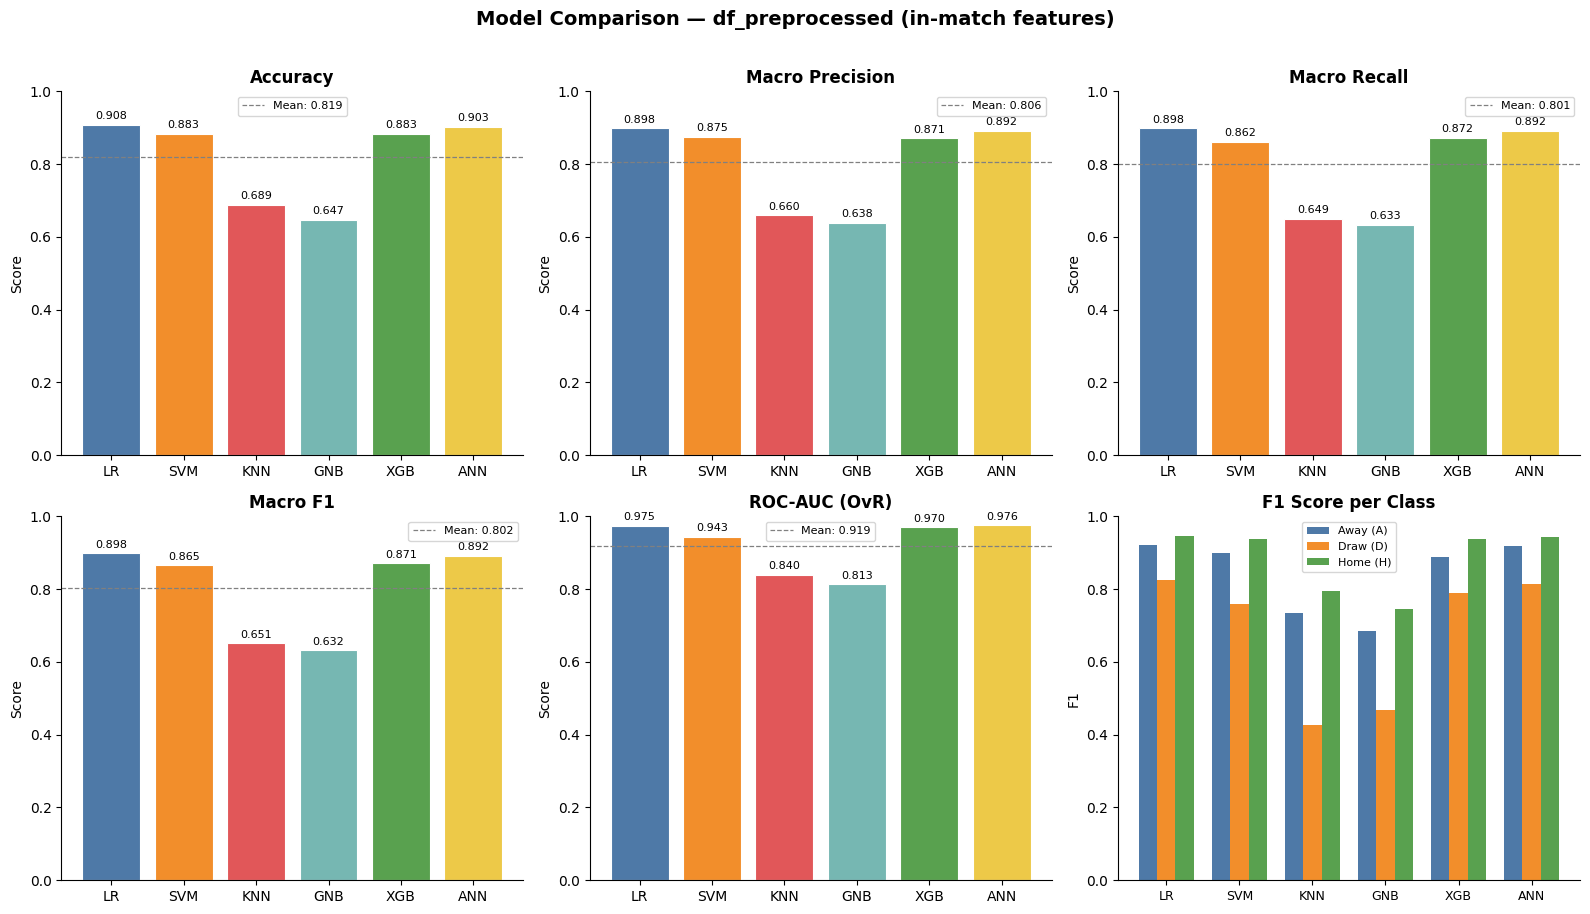

In [ ]:
# ── (2 × 3) bar chart grid ────────────────────────────────────────────────────
model_names = [r['name'] for r in all_results]

metrics_to_plot = [
    ('Accuracy',        [r['accuracy']       for r in all_results]),
    ('Macro Precision', [r['macro_precision'] for r in all_results]),
    ('Macro Recall',    [r['macro_recall']    for r in all_results]),
    ('Macro F1',        [r['macro_f1']        for r in all_results]),
    ('ROC-AUC (OvR)',   [r['roc_auc']         for r in all_results]),
    ('F1 per Class',    None),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax_i, (metric_name, values) in enumerate(metrics_to_plot):
    ax = axes[ax_i]
    if metric_name == 'F1 per Class':
        x     = np.arange(len(SHORT_NAMES))
        width = 0.25
        f1_a  = [r['f1_per_class'][0] for r in all_results]
        f1_d  = [r['f1_per_class'][1] for r in all_results]
        f1_h  = [r['f1_per_class'][2] for r in all_results]
        ax.bar(x - width, f1_a, width, label='Away (A)', color='#4e79a7')
        ax.bar(x,         f1_d, width, label='Draw (D)', color='#f28e2b')
        ax.bar(x + width, f1_h, width, label='Home (H)', color='#59a14f')
        ax.set_xticks(x); ax.set_xticklabels(SHORT_NAMES, fontsize=9)
        ax.set_ylim(0, 1); ax.set_title('F1 Score per Class', fontsize=12, fontweight='bold')
        ax.legend(fontsize=8); ax.set_ylabel('F1')
        for spine in ['top','right']: ax.spines[spine].set_visible(False)
    else:
        bars = ax.bar(SHORT_NAMES, values, color=PALETTE, edgecolor='white', linewidth=0.8)
        ax.set_ylim(0, 1)
        ax.set_title(metric_name, fontsize=12, fontweight='bold')
        ax.set_ylabel('Score')
        ax.axhline(y=np.mean(values), color='grey', linestyle='--', linewidth=0.9,
                   label=f'Mean: {np.mean(values):.3f}')
        ax.legend(fontsize=8)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)
        for spine in ['top','right']: ax.spines[spine].set_visible(False)

fig.suptitle('Model Comparison — df_preprocessed (in-match features)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


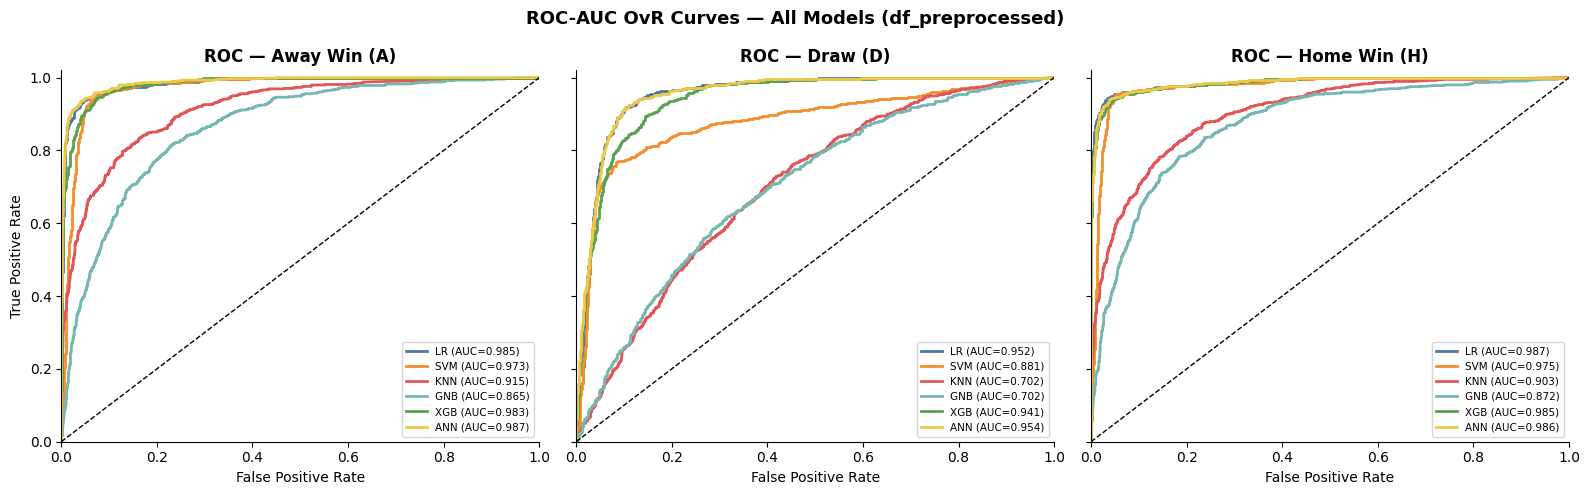

In [ ]:
# ── ROC-AUC OvR curves — all 6 models, 3 class panels ────────────────────────
COLORS = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
class_titles = ['Away Win (A)', 'Draw (D)', 'Home Win (H)']

for cls_i, ax in enumerate(axes):
    for m_i, r in enumerate(all_results):
        fpr, tpr, _ = roc_curve(y_te_bin[:, cls_i], r['y_prob'][:, cls_i])
        roc_val = sk_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=COLORS[m_i], lw=2,
                label=f'{SHORT_NAMES[m_i]} (AUC={roc_val:.3f})')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('False Positive Rate')
    if cls_i == 0: ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC — {class_titles[cls_i]}', fontweight='bold')
    ax.legend(fontsize=7.5, loc='lower right')
    for spine in ['top','right']: ax.spines[spine].set_visible(False)

fig.suptitle('ROC-AUC OvR Curves — All Models (df_preprocessed)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


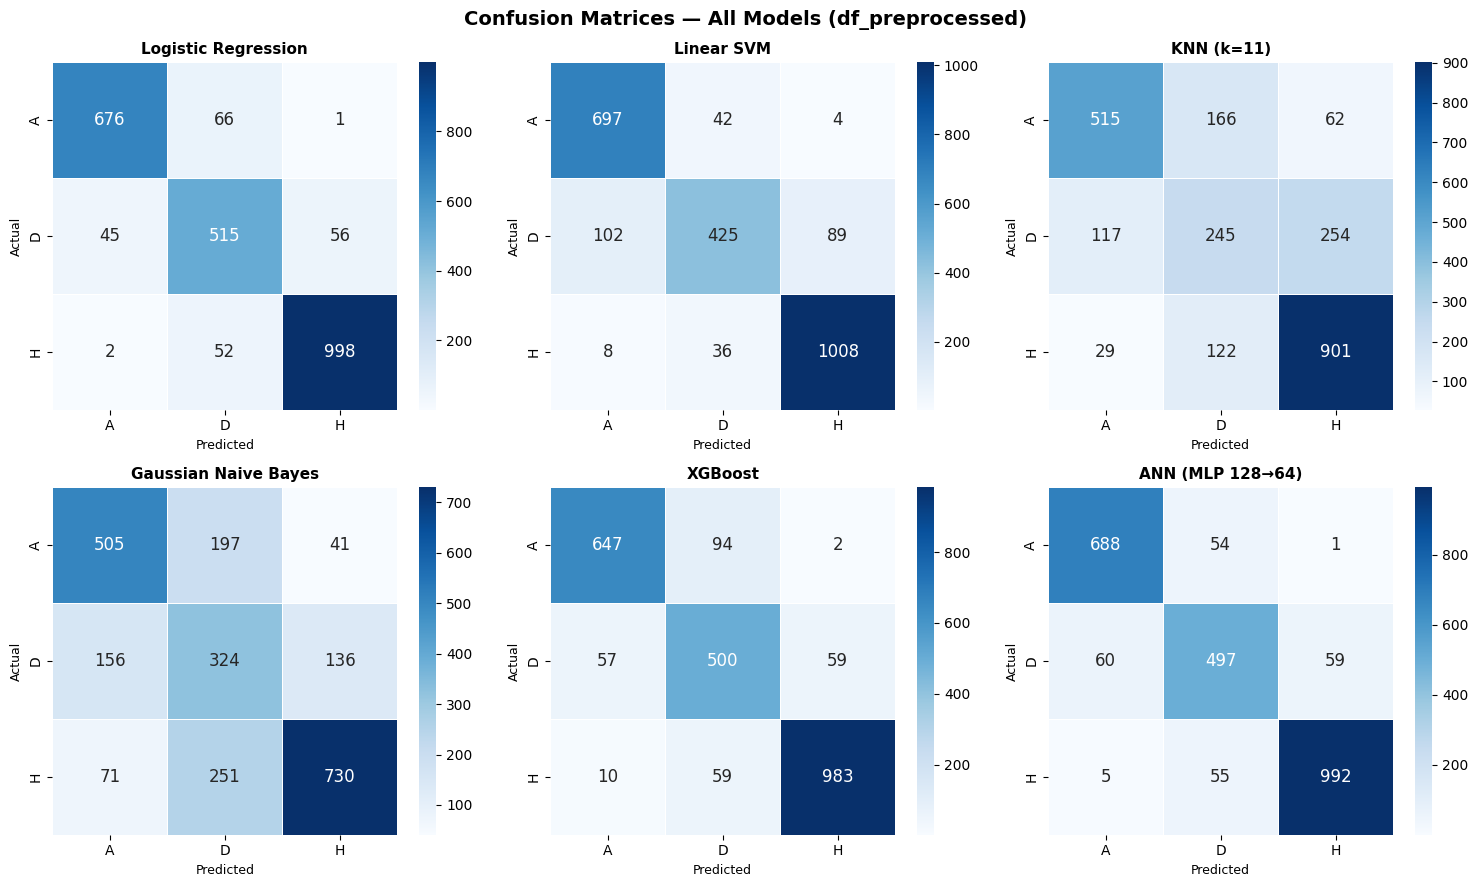

In [ ]:
# ── (2 × 3) confusion matrix grid ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax_i, r in enumerate(all_results):
    sns.heatmap(
        r['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_SHORT, yticklabels=CLASS_SHORT,
        ax=axes[ax_i], linewidths=0.5, linecolor='white',
        annot_kws={'size': 12}
    )
    axes[ax_i].set_title(r['name'], fontsize=11, fontweight='bold')
    axes[ax_i].set_xlabel('Predicted', fontsize=9)
    axes[ax_i].set_ylabel('Actual', fontsize=9)

fig.suptitle('Confusion Matrices — All Models (df_preprocessed)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
